# Overview
This notebook computes fluid dynamics quantities (given parameters of nitrogen gas and tubing) including:
- flow impedance using Darcy–Weisbach equation

$$Z = f \cdot \frac{L}{D} \cdot \frac{V^2}{2g}$$
$$\Delta P = \rho g Z = f \cdot \frac{L}{D} \cdot \frac{\rho V^2}{2}$$

- flow rate using Hagen-Poiseuille equation, expressed as:
$$\Delta P = \frac{8\mu LQ}{\pi R^4}$$
$$Q = \frac{\Delta P \pi R^4}{8\mu L}$$
- Reynolds number
- 

These quantities are defined and described in the Methods section.

## Imports

In [1]:
# Plotting
import matplotlib.pyplot as plt

# Vector math
import numpy as np

## Nitrogen gas constants 

In [2]:
# Dynamic viscosity of nitrogen at STP
MU = 1.7e-5     # Pa*s

# Universal gas constant
GAS_CONSTANT = 8.314        # J/(mol*K)

# Molar volume of an ideal gas at STP
MOLAR_VOLUME = 22.4         # L/mol

# Temperature, STP
TEMPERATURE_STP = 273.15    # K

# Density of nitrogen at STP
RHO_STP = 1.2506            # kg/m^3

## Unit conversions

In [9]:
# Inches to meters conversion factor
inch_to_meter = 0.0254

# Cubic meters per second to liters per minute conversion factor
m3s_to_lpm = 60000

# PSI to Pascals conversion factor
psi_to_pa = 6894.76

# SCFH to liters per minute conversion factor
scfh_to_lpm = 28.3168 / 60

## Methods

In [ ]:
# Cross sectional area
def calculate_cross_sectional_area(d):
    r = d / 2
    A = np.pi * r**2
    return A

# Hagen-Poiseuille equation
# Describes the pressure drop across a cylindrical tube of constant cross-sectional area for laminar flow.
def calculate_hagen_poiseuille(dp, r, l, mu):
    """
    Parameters:
        dp: Pressure drop across the tube (Pa)
        r: Radius of the tube (m)   
        l: Length of the tube (m)
        mu: Dynamic viscosity of the fluid (Pa*s)
    Returns:
        flow_rate: Volumetric flow rate (m^3/s)
        impedance: Hydraulic impedance (Pa*s/m^3)

    Governing relation for flow is flow Q * impedance Z = pressure drop dP
    Here, impedance Z = (8 * mu * l) / (pi * r^4) for laminar flow in a cylindrical tube.
    """
    impedance = (8 * mu * l) / (np.pi * r**4)   # Pa*s/m^3
    flow_rate = dp / impedance                  # m^3/s
    return flow_rate, impedance

# Reynolds number (unitless)
# This predicts whether the flow is laminar or turbulent. For laminar flow, Re < 2300. Turbulent flow occurs when Re > 4000. The range in between is transitional.
def calculate_reynolds_number(rho, v, d, mu):
    """
    Parameters:
        rho: Fluid density
        v: Flow velocity (speed)
        d: Characteristic length or dimension (e.g., pipe diameter)
        mu: Dynamic viscosity
        
        A typical quantity is also nu: Kinematic viscosity (nu = mu / rho)

    For convenience, returns: 
    (
        float: Reynolds number, 
        bool : flow type
    )

    Flow type:
        True if flow is laminar
        False if turbulent
        None if transitional
    """
    reynolds = (rho * v * d) / mu

    if reynolds < 2300:
        return reynolds, True
    elif reynolds > 4000:
        return reynolds, False
    else:
        return reynolds, None  # Transitional flow

# Blasius formula, giving the Darcy friction factor for turbulent flow in smooth pipes.
# Used to calculate the Darcy–Weisbach impedance
# Accurate for Reynolds number between 4000 and 100,000 (tubulent flow).
def calculate_friction_factor(reynolds):
    factor = 0.3164 * reynolds**(-0.25)
    return factor

# Darcy–Weisbach impedance: for incompressible fluid in a smooth cylindrical pipe.
def calculate_darcy_weisbach_impedance(friction_factor, l, d, rho, v, Q):
    """
    Parameters:
        friction_factor: Calculated using the Blasius equation for turbulent flow
        l: Length of the tube
        d: Diameter of the tube
        rho: Density of the fluid
        v: Flow velocity
        Q: Volumetric flow rate

    Note: expression is usually proportional to 1/g.
    But since Q = rho*g, we express as proportional to rho/Q so we can input a volumetric flow rate.
    """
    impedance = friction_factor * (l / d) * (rho * v**2) / (2 * Q)    # Pa*s/m^3
    return impedance

# Calculates pressure increase rate for a given flow rate and volume, using ideal gas law.
def pressure_increase_rate(
    flow_slpm, 
    chamber_volume_m3, 
    temperature_K=TEMPERATURE_STP, 
    molar_volume_L_per_mol=MOLAR_VOLUME
):
    """
    Calculate pressure increase rate (dP/dt) in Pascals per minute in a fixed volume chamber.

    Parameters:
    - flow_slpm: flow rate at STP (litres per minute)
    - chamber_volume_m3: chamber volume in cubic meters
    - temperature_K: temperature in Kelvin (default 298 K)
    - molar_volume_L_per_mol: molar volume at STP in litres per mole (default 22.4 L/mol)

    Returns:
    - pressure increase rate in Pascals per minute

    Notes: From ideal gas law P = (n/V) * R * T, we can derive dP/dt = (R * T / V) * dn/dt, where dn/dt is the molar flow rate.
    """

    # flow rate to moles per minute
    dn_dt = flow_slpm / molar_volume_L_per_mol  # mol/min

    # dP/dt in Pascals per minute
    dP_dt = (GAS_CONSTANT * temperature_K / chamber_volume_m3) * dn_dt  # Pa/min

    return dP_dt

## Analysis

### Tubing impedances for laminar and turbulent flow

In [5]:
# For laminar flow, calculate impedance and flow rate for tube at a given differential pressure (dP)

# Tube diameter and length
d = 0.295 * inch_to_meter
r = d/2
l = 1  # in meters

# Pressure drop (dP) across tube in Pascals
dp = 20 * psi_to_pa

flow, impedance = calculate_hagen_poiseuille(dp, r, l, MU)
flow_lpm = flow * m3s_to_lpm

print(f"Flow rate: {flow_lpm:.2f} L/min")
print(f"Impedance: {impedance:.2e} Pa*s/m^3")

Flow rate: 37653.40 L/min
Impedance: 2.20e+05 Pa*s/m^3


In [6]:
# Calculate Reynolds number
cross_area = calculate_cross_sectional_area(d)  
velocity = flow / cross_area
print("velocity (in m/s)", velocity)

Re, laminar = calculate_reynolds_number(RHO_STP, velocity, d, MU)
print(f"Re: {Re:.2f}")
print("Turbulent flow?", not laminar)

velocity (in m/s) 14231.531427772059
Re: 7844709.61
Turbulent flow? True


In [7]:
# Friction factor for turbulent flow
blasius = calculate_friction_factor(Re)
print("Blasius friction factor:", blasius)

# Calculate Darcy–Weisbach impedance (turbulent flow)
impedance = calculate_darcy_weisbach_impedance(blasius, l, d, RHO_STP, velocity, flow)
print("Impedance using Darcy–Weisbach (Pa*s/m^3):", impedance)

Blasius friction factor: 0.005978500320822477
Impedance using Darcy–Weisbach (Pa*s/m^3): 161018302.02688527


### Pressure changes in a volume for varying input flow rate

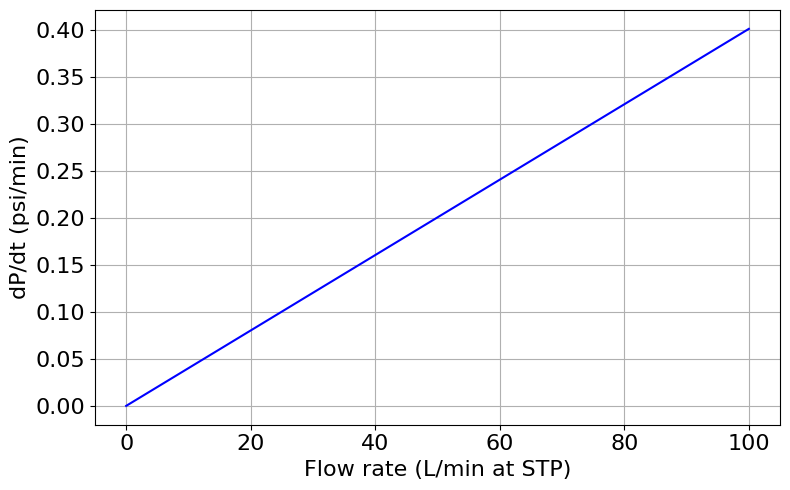

In [ ]:
# Plotting pressure increase rate vs flow rate for a fixed volume chamber, using ideal gas law.
# Relates possible input flow rates from the purge system Flow Controller to the pressure increase rate in the radon barrier volume.
# Note: the flow rate of the flow controller will be changing in response to changing differential pressure. But this plot allows us to  see directly what the pressure increase rate would be for the maximum flow rate (once measured) and for the normal operation case where dP is steady (flow will be constant at some measured value).

# Parameters
volume = 4            # chamber volume in cubic meters
temperature = 298     # room temperature in Kelvin

# Flow rates
flow_rates = np.linspace(0, 100, 100)

# Calculate pressure increase rates for all flow rates
pressure_rates = [pressure_increase_rate(fr, volume, temperature_K=temperature) / psi_to_pa for fr in flow_rates]

# Plotting
plt.figure(figsize=(8,5))
plt.plot(flow_rates, pressure_rates, linestyle='-', color='b')
plt.xlabel("Flow rate (L/min at STP)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("dP/dt (psi/min)", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
## Calculate how much max flow you get out of the check valve with flow coefficient for a given cracking pressure
def nitrogen_flow_from_cv_avgP(Cv, P1_psi, P2_psi, T_C, G=0.967):
    """
    Calculates nitrogen gas flow (std L/min) from Cv using the average pressure method.

    Parameters:
    Cv       : Valve flow coefficient (litres per min of water per 1 psi drop)
    P1_psi   : Inlet pressure (psia)
    P2_psi   : Outlet pressure (psia)
    T_C      : Temperature in Celsius
    G        : Specific gravity of gas (default for N2 = 0.967)

    Returns:
    Q_stdLmin : Flow rate in standard liters per minute
    """
    # Convert temperature to Rankine
    T_R = (T_C + 273.15) * 1.8

    # Calculate pressure drop and average pressure
    dP = P1_psi - P2_psi
    P_avg = (P1_psi + P2_psi) / 2

    if dP <= 0:
        return 0  # No flow if backpressure is too high

    # Flow in SCFH
    Q_scfh = 1360 * Cv * (dP / (G * T_R))**0.5 * P_avg**0.5

    # Convert SCFH to standard liters per minute
    Q_stdLmin = Q_scfh * 28.3168 / 60

    return Q_stdLmin

# Cracking presssure = P2_psi-P1_psi=0.1 psi
flow = nitrogen_flow_from_cv_avgP(Cv=68, P1_psi=18, P2_psi=17.9, T_C=20)
print(f"Computed flow (avg pressure method): {flow:.3f} std L/min")

Computed flow (avg pressure method): 2588.681 std L/min


## Choked flow rate
When flow is passing through an orifice, is the flow choking. For a choked flow, velocity is constant regardless of increase in dP. Is the flow choked? If yes, what is the flow rate out?
$$\dot{m} = C_d A P_t \sqrt{\frac{\gamma}{R T_t}} \left( \frac{2}{\gamma + 1} \right)^{\frac{\gamma + 1}{2(\gamma - 1)}}$$

In [ ]:
# Methods
def choked_flowrate(Cd, ):
    mass_flow = Cd * A * P1 * np.sqrt(gamma / (R * T0)) * (2 / (gamma + 1))**((gamma + 1) / (2 * (gamma - 1)))
    return mass_flow

# Constants
Cd = 0.8                     # Discharge coefficient
gamma = 1.4                  # ratio of specific heats for Nitrogen
R = 296.8                    # J/kg.K for Nitrogen
T0 = 293.15                  # K (20°C)
P1_psi = 19                  # upstream pressure in psi (absolute)
P2_psi = 17                  # downstream pressure in psi (absolute)
P1 = P1_psi * 6894.76        # Convert to Pa
P2 = P2_psi * 6894.76
rho_stp = 1.2506             # kg/m³ at STP

# Orifice diameter (3/8 inch)
d_inch = 3/8
d_m = d_inch * 0.0254        # Convert to meters
A = np.pi * (d_m/2)**2       # Area in m²

# Choking pressure ratio
choke_ratio = (2 / (gamma + 1))**(gamma / (gamma - 1))

# Check for choked flow
if P2 / P1 <= choke_ratio:
    print("Flow is choked.")
    mass_flow = choked_flowrate()
else:
    print("Flow is subsonic.")
    term1 = (2 * gamma) / (gamma - 1)
    term2 = (P2 / P1)**(2 / gamma)
    term3 = (P2 / P1)**((gamma + 1) / gamma)
    mass_flow = Cd * A * P1 * np.sqrt((term1 / (R * T0)) * (1 - term2 + term3))

# Convert to volumetric flow at STP
vol_flow_m3_s = mass_flow / rho_stp
vol_flow_lpm = vol_flow_m3_s * 1000 * 60  # convert m³/s to L/min

print(f"Volumetric flow rate (L/min): {vol_flow_lpm:.2f}")

## Check valve flow rate
Plot the maximum flow rate through a check valve for varying differential pressures across it.
Dependent variables include:
- parameters for nitrogen gas
- parameters of the tube in the path of the check valve (diameter and length)
- 

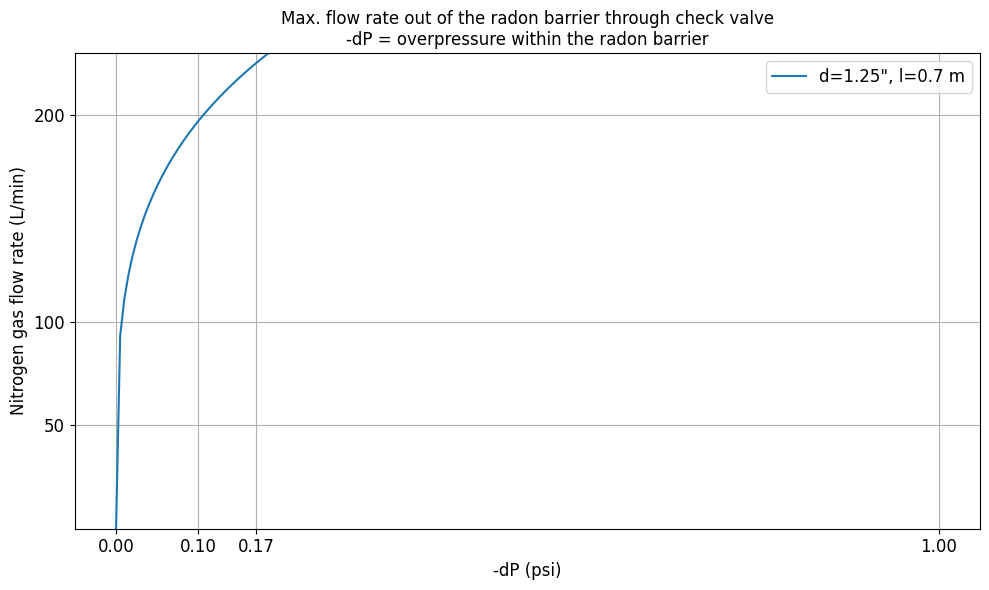

In [ ]:
# Nitrogen at STP
eta = 1.7e-5   # Pa·s
rho = 1.165     # kg/m³

# dP
dp_psi_array = np.linspace(0, 1, 200)
dp_array = dp_psi_array * 6894.6  # Convert to Pa

# Tube diameters in inches
diameters_inches = [0.5, 0.75, 1, 1.25, 1.5]
diameters_meters = [d * 0.0254 for d in diameters_inches]  # Convert to meters

# Tube lengths in meters
length_list = [0.7]  

plt.figure(figsize=(10, 6))

for l_fixed in length_list:
    for d_m in diameters_meters:
        r_fixed = d_m / 2
        A = np.pi * r_fixed**2

        Q_out_lpm = []
        Re_at_max_flow = None

        for dp_psi, dp in zip(dp_psi_array, dp_array):
            # Use Poiseuille-Hagen equation for Re < 4000 and Darcy-Weisbach for Re > 4000
            Z_poiseuille = (8 * eta * l_fixed) / (np.pi * r_fixed**4)
            Q_poiseuille = dp / Z_poiseuille
            v = Q_poiseuille / A
            Re = (rho * v * d_fixed) / eta

            if Re <= 4000:
                Q_used = Q_poiseuille
            else:
                f = 0.3164 * Re**(-0.25)
                Z_darcy = f * (l_fixed / d_fixed) * (rho * v**2) / (2 * Q_poiseuille)
                Q_used = dp / Z_darcy

            Q_lpm = Q_used * 60 * 1000  # Convert m³/s to L/min
            Q_out_lpm.append(Q_lpm)

            # Optional print for debugging
            #print(f'dP = {dp_psi:.2f} psi -> Flow rate = {Q_lpm:.2f} L/min')

            # Reynolds number for max ΔP
            if dp == dp_array[-1]:
                v_max = Q_used / A
                Re_at_max_flow = (rho * v_max * d_fixed) / eta

        label = f'd={d_inch} in, l={l_fixed} m'
        plt.plot(dp_psi_array, Q_out_lpm, label=label)

plt.xlabel("-dP (psi)", fontsize=12)
plt.ylabel("Nitrogen gas flow rate (L/min)", fontsize=12)
plt.title("Max. flow rate out of the radon barrier through check valve\n-dP = overpressure within the radon barrier", fontsize=12)
plt.xticks([0,0.1,0.17,1], fontsize=12)
plt.yticks([50,100,200,300,400])
plt.yticks(fontsize=12)
plt.ylim(0,230)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()